In [23]:
import pandas as pd
import seaborn as sns
from glob import glob
sns.set_theme(style="ticks", font="Linux Biolinum O", font_scale=1.2)

frames = [pd.read_csv(data) for data in glob('../data/operation-*.txt')]
for frame in frames:
    if 'num_participant' not in frame:
        frame['num_participant'] = 10000
data = pd.concat(frames, ignore_index=True)
data = data[data['comment'].isna()]

data = data[data['num_participant'] == 10000]
data = data[(data['inner_k'] == 32) & (data['inner_n'] == 80) & (data['outer_k'] == 8) & (data['outer_n'] == 10)]

def protocol_operation(row):
    return f'{row["protocol"].capitalize()} - {row["operation"]}'

data["Protocol - Operation"] = data.apply(protocol_operation, axis=1)
data

,comment,peer,operation,latency,protocol,inner_k,inner_n,outer_k,outer_n,num_concurrent,num_participant,key,Protocol - Operation
92,NaN,http://ec2-18-192-100-117.eu-central-1.compute...,put,19.907004,entropy,32.0,80.0,8.0,10.0,64.0,10000.0,NaN,Entropy - put
93,NaN,http://ec2-3-71-206-104.eu-central-1.compute.a...,put,20.397559,entropy,32.0,80.0,8.0,10.0,64.0,10000.0,NaN,Entropy - put
94,NaN,http://ec2-3-79-246-123.eu-central-1.compute.a...,put,19.840096,entropy,32.0,80.0,8.0,10.0,64.0,10000.0,NaN,Entropy - put
95,NaN,http://ec2-3-123-254-146.eu-central-1.compute....,put,20.020274,entropy,32.0,80.0,8.0,10.0,64.0,10000.0,NaN,Entropy - put
96,NaN,http://ec2-3-120-146-178.eu-central-1.compute....,put,20.518950,entropy,32.0,80.0,8.0,10.0,64.0,10000.0,NaN,Entropy - put
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21380,NaN,NaN,repair,4.540290,kademlia,32.0,80.0,8.0,10.0,560.0,10000.0,559c5fcb9c08aba4d2c152019884919f5a54a71e2394ca...,Kademlia - repair
21381,NaN,NaN,repair,4.789241,kademlia,32.0,80.0,8.0,10.0,560.0,10000.0,b547c555cb1b448108120b8bf35fd566b09cbf1ddcd602...,Kademlia - repair
21382,NaN,NaN,repair,4.088777,kademlia,32.0,80.0,8.0,10.0,560.0,10000.0,aba2430cf0cfa769a3f325bb2d4a1715bcc4dfe2405b2f...,Kademlia - repair
21383,NaN,NaN,repair,4.085679,kademlia,32.0,80.0,8.0,10.0,560.0,10000.0,91a44dbe9ec1403783c98f163677cfd50d4ab0ead1715e...,Kademlia - repair


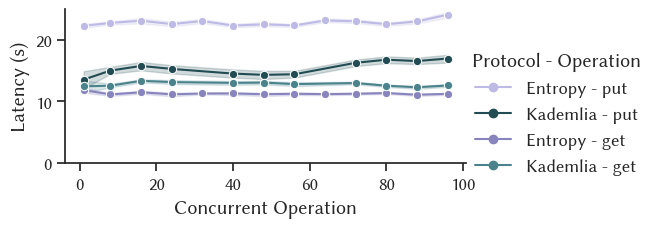

In [24]:
hue_order = ["Entropy - put", "Kademlia - put", "Entropy - get", "Kademlia - get"]
entropy_palette = sns.cubehelix_palette(rot=0., light=0.75, n_colors=4)
kademlia_palette = sns.cubehelix_palette(start=2.5, rot=0., dark=0.25, n_colors=4)
palette = [c for p in zip(entropy_palette, reversed(kademlia_palette)) for c in p]

sns.relplot(data=data[data['operation'] != 'repair'],
    kind="line",
    x="num_concurrent", y="latency", hue="Protocol - Operation",
    hue_order=hue_order, palette=palette[:4],
    markers=['o'] * 4, dashes=False, style='Protocol - Operation',
    height=2.56, aspect=2.) \
.set_xlabels("Concurrent Operation") \
.set_ylabels("Latency (s)") \
.set(ylim=[0, 25]) \
.savefig("../../graphs/concurrent-put-get.pdf")

/tmp/ipykernel_922660/4141478458.py:3: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.relplot(data=data[data['operation'] == 'repair'],


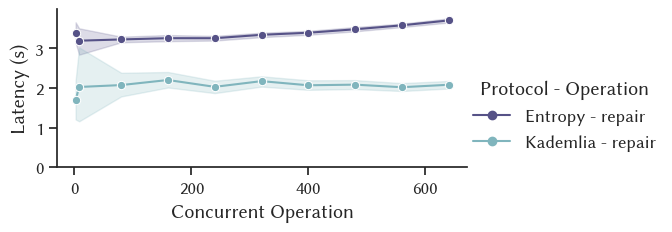

In [25]:
hue_order = ["Entropy - repair", "Kademlia - repair"]

sns.relplot(data=data[data['operation'] == 'repair'],
    kind="line",
    x="num_concurrent", y="latency", hue="Protocol - Operation",
    hue_order=hue_order, palette=palette[4:],
    markers=['o'] * 2, dashes=False, style='Protocol - Operation',
    height=2.56, aspect=2.) \
.set_xlabels("Concurrent Operation") \
.set_ylabels("Latency (s)") \
.set(ylim=[0, 3.99]) \
.savefig("../../graphs/concurrent-repair.pdf")